1. Імпортуємо бібліотеки:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             matthews_corrcoef, classification_report)
from sklearn.inspection import permutation_importance
import time
import warnings
warnings.filterwarnings('ignore')

# Налаштування візуалізації
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 80)
print("Імпортовано!")
print("=" * 80)

Імпортовано!


2. Завантажуємо та обробляємо дані:

In [2]:
print("\n[1] ЗАВАНТАЖЕННЯ ТА ПОПЕРЕДНЯ ОБРОБКА ДАНИХ")
print("-" * 80)

# Завантаження даних
df = pd.read_csv('synthetic_coffee_health_10000.csv')
print(f" Датасет завантажено: {df.shape[0]} записів, {df.shape[1]} ознак")
print(f"\nПерші 5 рядків:\n{df.head()}")
print(f"\nІнформація про датасет:\n{df.info()}")
print(f"\nСтатистика:\n{df.describe()}")
print(f"\nРозподіл цільової змінної Health_Issues:\n{df['Health_Issues'].value_counts()}")

# Видалення ID
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)
    print("\n Колонка 'ID' видалена")

# Перевірка пропущених значень
print(f"\nПропущені значення:\n{df.isnull().sum()}")

# Розділення на ознаки та цільову змінну
X = df.drop('Health_Issues', axis=1)
y = df['Health_Issues']

# КРИТИЧНО ВАЖЛИВО: Видалення рядків з пропущеними значеннями в цільовій змінній
print(f"\nПропущені значення в Health_Issues: {y.isnull().sum()} ({y.isnull().sum()/len(y)*100:.2f}%)")
mask_valid = y.notna()
X = X[mask_valid]
y = y[mask_valid]
print(f" Після видалення NaN: {len(y)} записів")
print(f"\nОновлений розподіл Health_Issues:\n{y.value_counts()}")

# Кодування цільової змінної
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
class_names = [str(cls) for cls in le_target.classes_]
print(f"\n Цільова змінна закодована: {le_target.classes_}")

# Визначення категоріальних та числових ознак
categorical_cols = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level',
                    'Occupation', 'Smoking', 'Alcohol_Consumption']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print(f"\nЧислові ознаки ({len(numerical_cols)}): {numerical_cols}")
print(f"Категоріальні ознаки ({len(categorical_cols)}): {categorical_cols}")

# One-hot encoding для категоріальних ознак
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\n One-hot encoding виконано: {X_encoded.shape[1]} ознак після кодування")

# Розділення на тренувальну та тестову вибірки (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\n Дані розділено:")
print(f"  - Тренувальна вибірка: {X_train.shape[0]} зразків")
print(f"  - Тестова вибірка: {X_test.shape[0]} зразків")





[1] ЗАВАНТАЖЕННЯ ТА ПОПЕРЕДНЯ ОБРОБКА ДАНИХ
--------------------------------------------------------------------------------
 Датасет завантажено: 10000 записів, 16 ознак

Перші 5 рядків:
   ID  Age  Gender  Country  Coffee_Intake  Caffeine_mg  Sleep_Hours  \
0   1   40    Male  Germany            3.5        328.1          7.5   
1   2   33    Male  Germany            1.0         94.1          6.2   
2   3   42    Male   Brazil            5.3        503.7          5.9   
3   4   53    Male  Germany            2.6        249.2          7.3   
4   5   32  Female    Spain            3.1        298.0          5.3   

  Sleep_Quality   BMI  Heart_Rate Stress_Level  Physical_Activity_Hours  \
0          Good  24.9          78          Low                     14.5   
1          Good  20.0          67          Low                     11.0   
2          Fair  22.7          59       Medium                     11.2   
3          Good  24.7          71          Low                      6.6   
4  

3. Реалізовуємо дерево рішень з gini index:

In [3]:
print("\n" + "=" * 80)
print("РЕАЛІЗАЦІЯ ВЛАСНОГО ДЕРЕВА РІШЕНЬ З GINI INDEX")
print("=" * 80)

class MyDecisionTree:
    """Власна реалізація дерева рішень з використанням Gini Index"""

    def __init__(self, max_depth=5, min_samples=2):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.feature_importance = None
        self.tree = None
        self.n_features = None
        self.n_classes = None

    def gini(self, y):
        """Обчислення Gini impurity для вузла"""
        if len(y) == 0:
            return 0
        classes, counts = np.unique(y, return_counts=True)
        proportions = counts / len(y)
        gini = 1 - np.sum(proportions ** 2)
        return gini

    def best_split(self, X, y):
        """Знаходження найкращого розділу за мінімальним Gini"""
        best_gini = float('inf')
        best_feature = None
        best_threshold = None
        n_samples = len(y)

        if n_samples <= self.min_samples:
            return None, None, best_gini

        current_gini = self.gini(y)

        # Перебір всіх ознак
        for feature_idx in range(X.shape[1]):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)

            # Перебір можливих порогів
            for i in range(len(unique_values) - 1):
                threshold = (unique_values[i] + unique_values[i + 1]) / 2

                # Розділення на ліве та праве піддерева
                left_mask = feature_values <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) < self.min_samples or np.sum(right_mask) < self.min_samples:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Обчислення зваженого Gini
                n_left = len(y_left)
                n_right = len(y_right)
                weighted_gini = (n_left / n_samples) * self.gini(y_left) + \
                               (n_right / n_samples) * self.gini(y_right)

                # Оновлення найкращого розділу
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold, best_gini

    def build_tree(self, X, y, depth=0):
        """Рекурсивна побудова дерева"""
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # Критерії зупинки
        if depth >= self.max_depth or n_samples < self.min_samples or n_classes == 1:
            leaf_value = np.bincount(y.astype(int)).argmax()
            return {'leaf': True, 'class': leaf_value, 'n_samples': n_samples}

        # Знаходження найкращого розділу
        feature, threshold, best_gini = self.best_split(X, y)

        if feature is None:
            leaf_value = np.bincount(y.astype(int)).argmax()
            return {'leaf': True, 'class': leaf_value, 'n_samples': n_samples}

        # Обчислення важливості ознаки для цього вузла
        current_gini = self.gini(y)
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        n_left = np.sum(left_mask)
        n_right = np.sum(right_mask)

        # Feature importance: зважене зменшення Gini
        importance = (n_samples / self.n_total) * (current_gini - best_gini)
        self.feature_importance[feature] += importance

        # Рекурсивна побудова піддерев
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            'leaf': False,
            'feature': feature,
            'threshold': threshold,
            'left': left_subtree,
            'right': right_subtree,
            'n_samples': n_samples
        }

    def fit(self, X, y):
        """Навчання дерева та обчислення важливості ознак"""
        self.n_features = X.shape[1]
        self.n_classes = len(np.unique(y))
        self.n_total = len(y)
        self.feature_importance = np.zeros(self.n_features)

        self.tree = self.build_tree(X, y)

        # Нормалізація важливості
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)

        return self

    def predict_one(self, x, node):
        """Прогноз для одного зразка"""
        if node['leaf']:
            return node['class']

        if x[node['feature']] <= node['threshold']:
            return self.predict_one(x, node['left'])
        else:
            return self.predict_one(x, node['right'])

    def predict(self, X):
        """Прогноз для всіх зразків"""
        return np.array([self.predict_one(x, self.tree) for x in X])

    def count_leaves(self, node):
        """Підрахунок кількості листів у дереві"""
        if node['leaf']:
            return 1
        return self.count_leaves(node['left']) + self.count_leaves(node['right'])

    def get_depth(self, node=None):
        """Обчислення глибини дерева"""
        if node is None:
            node = self.tree
        if node['leaf']:
            return 1
        return 1 + max(self.get_depth(node['left']), self.get_depth(node['right']))



РЕАЛІЗАЦІЯ ВЛАСНОГО ДЕРЕВА РІШЕНЬ З GINI INDEX


4. Навчаємо влесне дерево рішень:

In [4]:
# Навчання власного дерева рішень
print("\nНавчання MyDecisionTree...")
start_time = time.time()
my_tree = MyDecisionTree(max_depth=10, min_samples=5)
my_tree.fit(X_train.values, y_train)
training_time = time.time() - start_time

print(f" Дерево побудовано за {training_time:.3f} секунд")
print(f"  - Глибина дерева: {my_tree.get_depth()}")
print(f"  - Кількість листів: {my_tree.count_leaves(my_tree.tree)}")

# Прогнозування
start_time = time.time()
y_pred_my = my_tree.predict(X_test.values)
prediction_time = time.time() - start_time

# Оцінка моделі
accuracy_my = accuracy_score(y_test, y_pred_my)
f1_my = f1_score(y_test, y_pred_my, average='weighted')
mcc_my = matthews_corrcoef(y_test, y_pred_my)

print(f"\n{'МЕТРИКИ MyDecisionTree':^80}")
print("-" * 80)
print(f"Accuracy:  {accuracy_my:.4f}")
print(f"F1-score:  {f1_my:.4f}")
print(f"MCC:       {mcc_my:.4f}")
print(f"Час прогнозування: {prediction_time:.4f} сек")

# Confusion Matrix
cm_my = confusion_matrix(y_test, y_pred_my)
print(f"\nConfusion Matrix:\n{cm_my}")

# Класифікаційний звіт
print(f"\nКласифікаційний звіт:")
print(classification_report(y_test, y_pred_my, target_names=class_names))




Навчання MyDecisionTree...
 Дерево побудовано за 1.487 секунд
  - Глибина дерева: 5
  - Кількість листів: 8

                             МЕТРИКИ MyDecisionTree                             
--------------------------------------------------------------------------------
Accuracy:  0.9938
F1-score:  0.9938
MCC:       0.9703
Час прогнозування: 0.0021 сек

Confusion Matrix:
[[716   0   0]
 [  5  88   0]
 [  0   0   3]]

Класифікаційний звіт:
              precision    recall  f1-score   support

        Mild       0.99      1.00      1.00       716
    Moderate       1.00      0.95      0.97        93
      Severe       1.00      1.00      1.00         3

    accuracy                           0.99       812
   macro avg       1.00      0.98      0.99       812
weighted avg       0.99      0.99      0.99       812



5. Реалізовуємо обрізку дерева рішень для зменшення перенавчання та покращення узагальнення моделі:

In [5]:

# ==================== б) PRUNING (ОБРІЗКА ДЕРЕВА) ====================
print("\n" + "=" * 80)
print("[3] РЕАЛІЗАЦІЯ PRUNING (УНИКНЕННЯ ПЕРЕНАВЧАННЯ)")
print("=" * 80)

class MyDecisionTreeWithPruning(MyDecisionTree):
    """Дерево рішень з підтримкою cost-complexity pruning"""

    def calculate_error(self, X, y, node):
        """Обчислення помилки на валідаційних даних"""
        predictions = np.array([self.predict_one(x, node) for x in X])
        return np.sum(predictions != y)

    def prune_tree(self, node, alpha, validation_X, validation_y):
        """Рекурсивна обрізка дерева з cost-complexity"""
        if node['leaf']:
            return 0

        # Рекурсивна обрізка піддерев
        left_error = self.prune_tree(node['left'], alpha, validation_X, validation_y)
        right_error = self.prune_tree(node['right'], alpha, validation_X, validation_y)

        # Помилка піддерева
        subtree_leaves = self.count_leaves(node)

        # Помилка, якщо зробити цей вузол листом
        majority_class = self._get_majority_class(node)
        leaf_node = {'leaf': True, 'class': majority_class}

        # Обчислюємо помилки локально для цього вузла
        mask = self._get_samples_in_node(validation_X, node)
        if np.sum(mask) > 0:
            node_X = validation_X[mask]
            node_y = validation_y[mask]

            subtree_error = self.calculate_error(node_X, node_y, node)
            leaf_error = self.calculate_error(node_X, node_y, leaf_node)

            # Cost-complexity критерій
            cost_subtree = subtree_error + alpha * subtree_leaves
            cost_leaf = leaf_error + alpha

            if cost_leaf <= cost_subtree:
                # Обрізаємо - перетворюємо на лист
                node['leaf'] = True
                node['class'] = majority_class
                if 'left' in node:
                    del node['left']
                if 'right' in node:
                    del node['right']
                if 'feature' in node:
                    del node['feature']
                if 'threshold' in node:
                    del node['threshold']
                return leaf_error

        return left_error + right_error

    def _get_majority_class(self, node):
        """Отримання majority class для вузла"""
        if node['leaf']:
            return node['class']
        # Рекурсивно збираємо класи з усіх листів
        classes = []
        self._collect_leaf_classes(node, classes)
        if classes:
            return np.bincount(classes).argmax()
        return 0

    def _collect_leaf_classes(self, node, classes):
        """Збір класів з усіх листів"""
        if node['leaf']:
            classes.extend([node['class']] * node['n_samples'])
        else:
            self._collect_leaf_classes(node['left'], classes)
            self._collect_leaf_classes(node['right'], classes)

    def _get_samples_in_node(self, X, node, path=None):
        """Отримання маски зразків, що потрапляють у вузол"""
        if path is None:
            return np.ones(len(X), dtype=bool)

        mask = np.ones(len(X), dtype=bool)
        current = self.tree

        for direction in path:
            if current['leaf']:
                break
            if direction == 'left':
                mask &= X[:, current['feature']] <= current['threshold']
                current = current['left']
            else:
                mask &= X[:, current['feature']] > current['threshold']
                current = current['right']

        return mask

    def fit_with_pruning(self, X_train, y_train, X_val, y_val, alpha=0.01):
        """Навчання з обрізкою"""
        # Спочатку будуємо повне дерево
        self.fit(X_train, y_train)

        print(f"\nДо обрізки:")
        print(f"  - Глибина: {self.get_depth()}")
        print(f"  - Кількість листів: {self.count_leaves(self.tree)}")

        # Застосовуємо pruning
        self.prune_tree(self.tree, alpha, X_val, y_val)

        # Переобчислюємо feature importance після pruning
        self.feature_importance = np.zeros(self.n_features)
        self._recalculate_importance(self.tree, X_train, y_train)
        if np.sum(self.feature_importance) > 0:
            self.feature_importance /= np.sum(self.feature_importance)

        print(f"\nПісля обрізки (alpha={alpha}):")
        print(f"  - Глибина: {self.get_depth()}")
        print(f"  - Кількість листів: {self.count_leaves(self.tree)}")

        return self

    def _recalculate_importance(self, node, X, y):
        """Переобчислення важливості ознак після pruning"""
        if node['leaf']:
            return

        feature = node['feature']
        threshold = node['threshold']

        current_gini = self.gini(y)
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        y_left = y[left_mask]
        y_right = y[right_mask]

        weighted_gini = (len(y_left) / len(y)) * self.gini(y_left) + \
                       (len(y_right) / len(y)) * self.gini(y_right)

        importance = (len(y) / self.n_total) * (current_gini - weighted_gini)
        self.feature_importance[feature] += importance

        self._recalculate_importance(node['left'], X[left_mask], y_left)
        self._recalculate_importance(node['right'], X[right_mask], y_right)



[3] РЕАЛІЗАЦІЯ PRUNING (УНИКНЕННЯ ПЕРЕНАВЧАННЯ)


6. Навчаємо дерева рішень з обрізкою, використовуючи розділення даних на тренувальні та валідаційні, а потім оцінюємо модель за основними метриками:

In [6]:
# Розділення тренувальних даних на train та validation для pruning
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"\nДані для pruning:")
print(f"  - Train: {X_train_split.shape[0]} зразків")
print(f"  - Validation: {X_val_split.shape[0]} зразків")

# Навчання дерева з pruning
pruned_tree = MyDecisionTreeWithPruning(max_depth=15, min_samples=2)
pruned_tree.fit_with_pruning(
    X_train_split.values, y_train_split,
    X_val_split.values, y_val_split,
    alpha=0.01
)

# Оцінка pruned дерева
y_pred_pruned = pruned_tree.predict(X_test.values)
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='weighted')
mcc_pruned = matthews_corrcoef(y_test, y_pred_pruned)

print(f"\n{'МЕТРИКИ Pruned Tree':^80}")
print("-" * 80)
print(f"Accuracy:  {accuracy_pruned:.4f}")
print(f"F1-score:  {f1_pruned:.4f}")
print(f"MCC:       {mcc_pruned:.4f}")

cm_pruned = confusion_matrix(y_test, y_pred_pruned)
print(f"\nConfusion Matrix:\n{cm_pruned}")


Дані для pruning:
  - Train: 2597 зразків
  - Validation: 650 зразків

До обрізки:
  - Глибина: 7
  - Кількість листів: 10

Після обрізки (alpha=0.01):
  - Глибина: 5
  - Кількість листів: 5

                              МЕТРИКИ Pruned Tree                               
--------------------------------------------------------------------------------
Accuracy:  0.9187
F1-score:  0.8988
MCC:       0.5349

Confusion Matrix:
[[716   0   0]
 [ 63  30   0]
 [  3   0   0]]


7. Порівнюємо із Sklearn:

In [7]:
# ==================== в) ПОРІВНЯННЯ З SKLEARN ====================
print("\n" + "=" * 80)
print("[4] ПОРІВНЯННЯ З SKLEARN (DecisionTree та RandomForest)")
print("=" * 80)

# sklearn DecisionTree
print("\nНавчання sklearn DecisionTreeClassifier...")
start_time = time.time()
dt_sklearn = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
dt_sklearn.fit(X_train, y_train)
dt_train_time = time.time() - start_time

start_time = time.time()
y_pred_dt = dt_sklearn.predict(X_test)
dt_pred_time = time.time() - start_time

accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
mcc_dt = matthews_corrcoef(y_test, y_pred_dt)

print(f" Навчання завершено за {dt_train_time:.3f} сек")
print(f"\n{'МЕТРИКИ sklearn DecisionTree':^80}")
print("-" * 80)
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"F1-score:  {f1_dt:.4f}")
print(f"MCC:       {mcc_dt:.4f}")
print(f"Час прогнозування: {dt_pred_time:.4f} сек")

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(f"\nConfusion Matrix:\n{cm_dt}")

# sklearn RandomForest
print("\n" + "-" * 80)
print("Навчання sklearn RandomForestClassifier...")
start_time = time.time()
rf_sklearn = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_sklearn.fit(X_train, y_train)
rf_train_time = time.time() - start_time

start_time = time.time()
y_pred_rf = rf_sklearn.predict(X_test)
rf_pred_time = time.time() - start_time

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print(f" Навчання завершено за {rf_train_time:.3f} сек")
print(f"\n{'МЕТРИКИ RandomForest':^80}")
print("-" * 80)
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"MCC:       {mcc_rf:.4f}")
print(f"Час прогнозування: {rf_pred_time:.4f} сек")

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f"\nConfusion Matrix:\n{cm_rf}")

# Cross-validation
print("\n" + "-" * 80)
print("5-Fold Cross-Validation:")
cv_scores_dt = cross_val_score(dt_sklearn, X_train, y_train, cv=5, scoring='accuracy')
cv_scores_rf = cross_val_score(rf_sklearn, X_train, y_train, cv=5, scoring='accuracy')

print(f"sklearn DecisionTree CV: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")
print(f"RandomForest CV:         {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")




[4] ПОРІВНЯННЯ З SKLEARN (DecisionTree та RandomForest)

Навчання sklearn DecisionTreeClassifier...
 Навчання завершено за 0.013 сек

                          МЕТРИКИ sklearn DecisionTree                          
--------------------------------------------------------------------------------
Accuracy:  0.9926
F1-score:  0.9925
MCC:       0.9643
Час прогнозування: 0.0023 сек

Confusion Matrix:
[[715   1   0]
 [  5  88   0]
 [  0   0   3]]

--------------------------------------------------------------------------------
Навчання sklearn RandomForestClassifier...
 Навчання завершено за 0.415 сек

                              МЕТРИКИ RandomForest                              
--------------------------------------------------------------------------------
Accuracy:  0.9815
F1-score:  0.9793
MCC:       0.9090
Час прогнозування: 0.0477 сек

Confusion Matrix:
[[716   0   0]
 [ 12  81   0]
 [  0   3   0]]

--------------------------------------------------------------------------------
5-

8. Будуємо порівняльну таблицю:

In [8]:
# ==================== ПОРІВНЯЛЬНА ТАБЛИЦЯ ====================
print("\n" + "=" * 80)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ ВСІХ МОДЕЛЕЙ")
print("=" * 80)

results_df = pd.DataFrame({
    'Model': ['MyDecisionTree', 'Pruned Tree', 'sklearn DT', 'RandomForest'],
    'Accuracy': [accuracy_my, accuracy_pruned, accuracy_dt, accuracy_rf],
    'F1-Score': [f1_my, f1_pruned, f1_dt, f1_rf],
    'MCC': [mcc_my, mcc_pruned, mcc_dt, mcc_rf],
    'Train Time (s)': [training_time, '-', dt_train_time, rf_train_time]
})

print(results_df.to_string(index=False))




ПОРІВНЯЛЬНА ТАБЛИЦЯ ВСІХ МОДЕЛЕЙ
         Model  Accuracy  F1-Score      MCC Train Time (s)
MyDecisionTree  0.993842  0.993768 0.970350        1.48707
   Pruned Tree  0.918719  0.898793 0.534943              -
    sklearn DT  0.992611  0.992540 0.964333       0.013446
  RandomForest  0.981527  0.979272 0.908987       0.415383


9. Візуалізуємо результати. 1) Порівняння метрик:


[5] ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ
 Графік порівняння метрик збережено: metrics_comparison.png


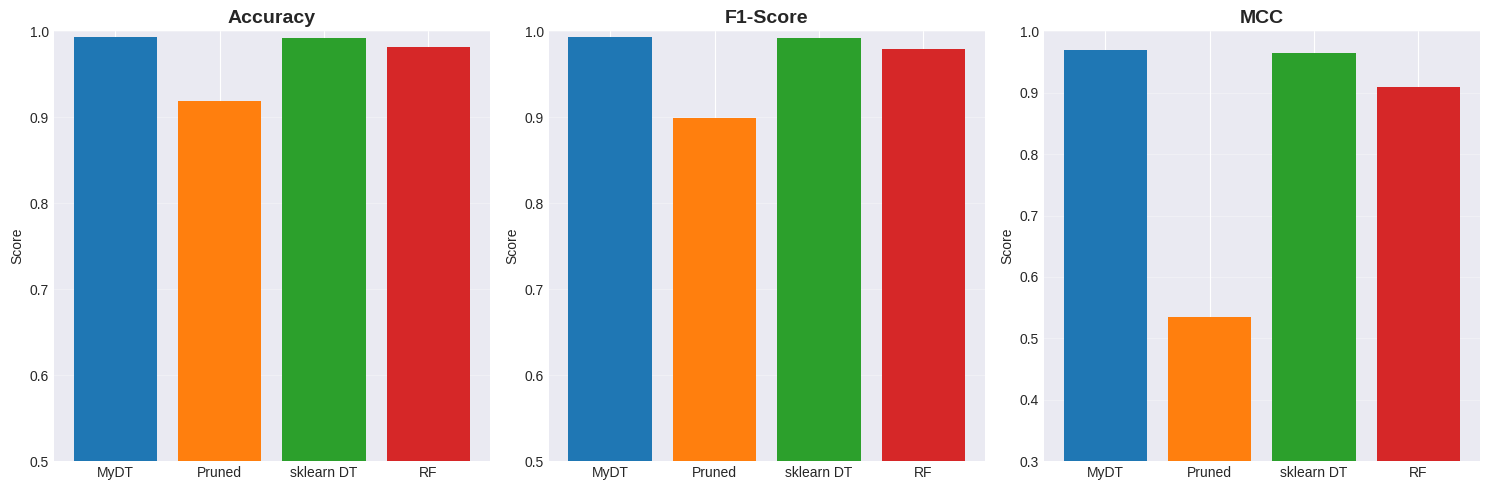

In [9]:
# ==================== ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ ====================
print("\n" + "=" * 80)
print("[5] ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ")
print("=" * 80)

# 1) Порівняння метрик
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['MyDT', 'Pruned', 'sklearn DT', 'RF']
accuracies = [accuracy_my, accuracy_pruned, accuracy_dt, accuracy_rf]
f1_scores = [f1_my, f1_pruned, f1_dt, f1_rf]
mccs = [mcc_my, mcc_pruned, mcc_dt, mcc_rf]

axes[0].bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(models, f1_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(models, mccs, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[2].set_title('MCC', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim([0.3, 1.0])
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
print(" Графік порівняння метрик збережено: metrics_comparison.png")
plt.show()

  2) Confusion Matrices:

 Confusion matrices збережено: confusion_matrices.png


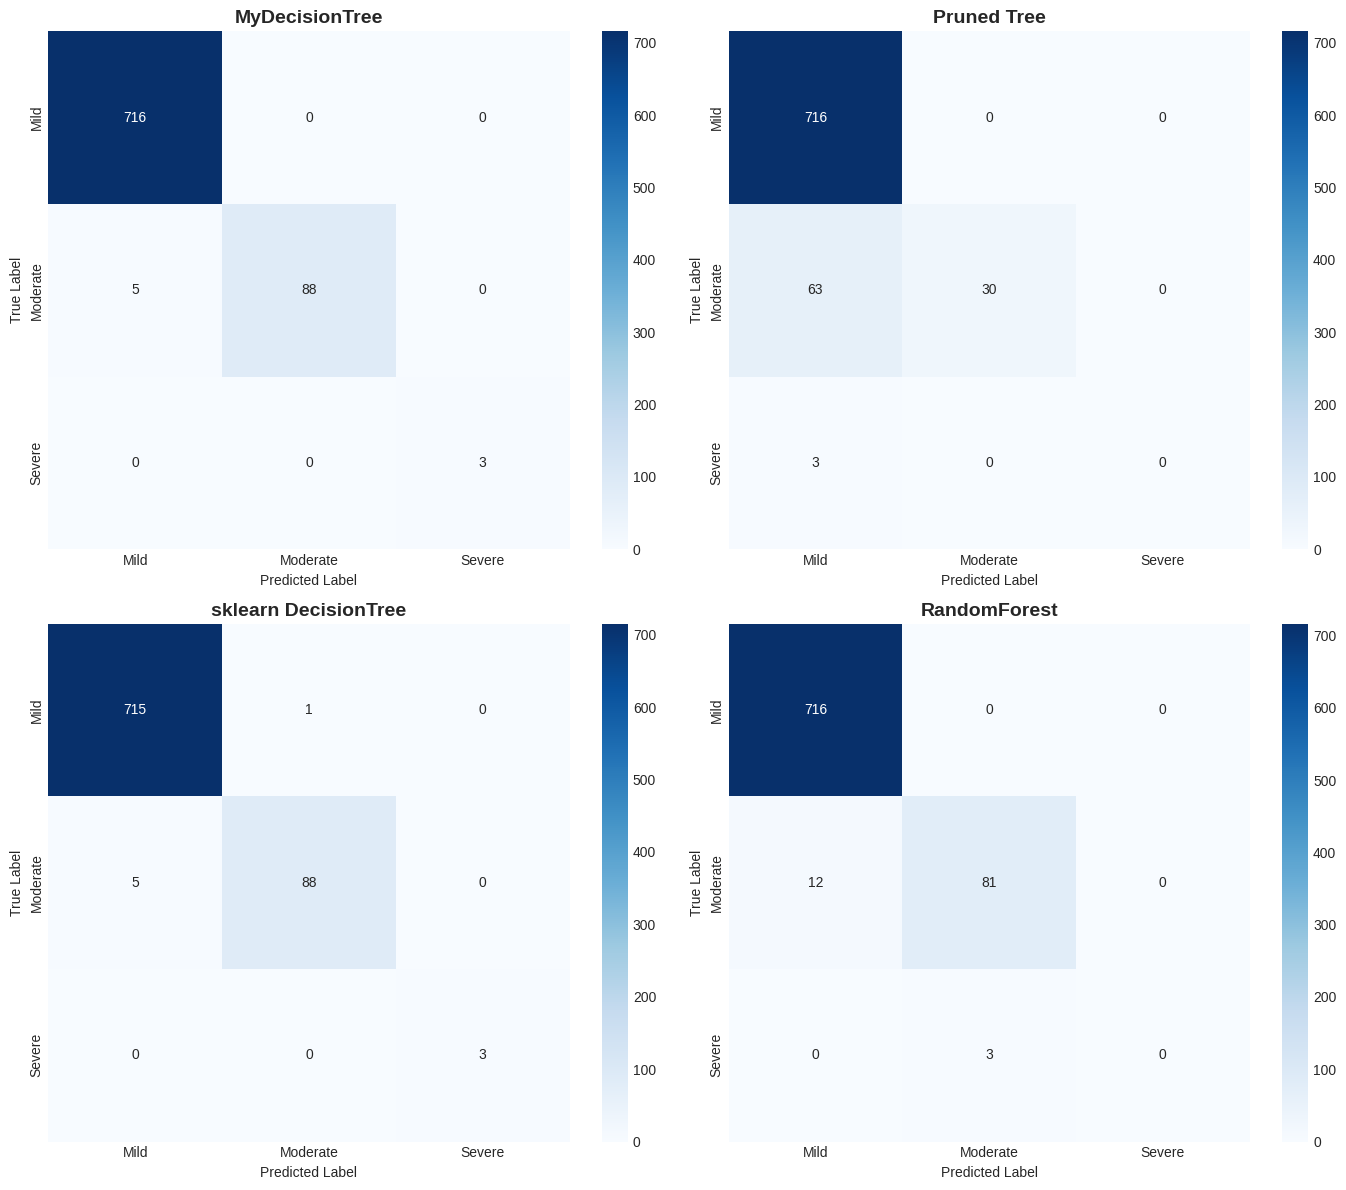

In [10]:
# 2) Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
cms = [cm_my, cm_pruned, cm_dt, cm_rf]
titles = ['MyDecisionTree', 'Pruned Tree', 'sklearn DecisionTree', 'RandomForest']

for idx, (cm, title) in enumerate(zip(cms, titles)):
    ax = axes[idx // 2, idx % 2]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names,
                yticklabels=class_names)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print(" Confusion matrices збережено: confusion_matrices.png")
plt.show()

3. Feature Importance порівняння:

 Feature importance графіки збережено: feature_importance_comparison.png


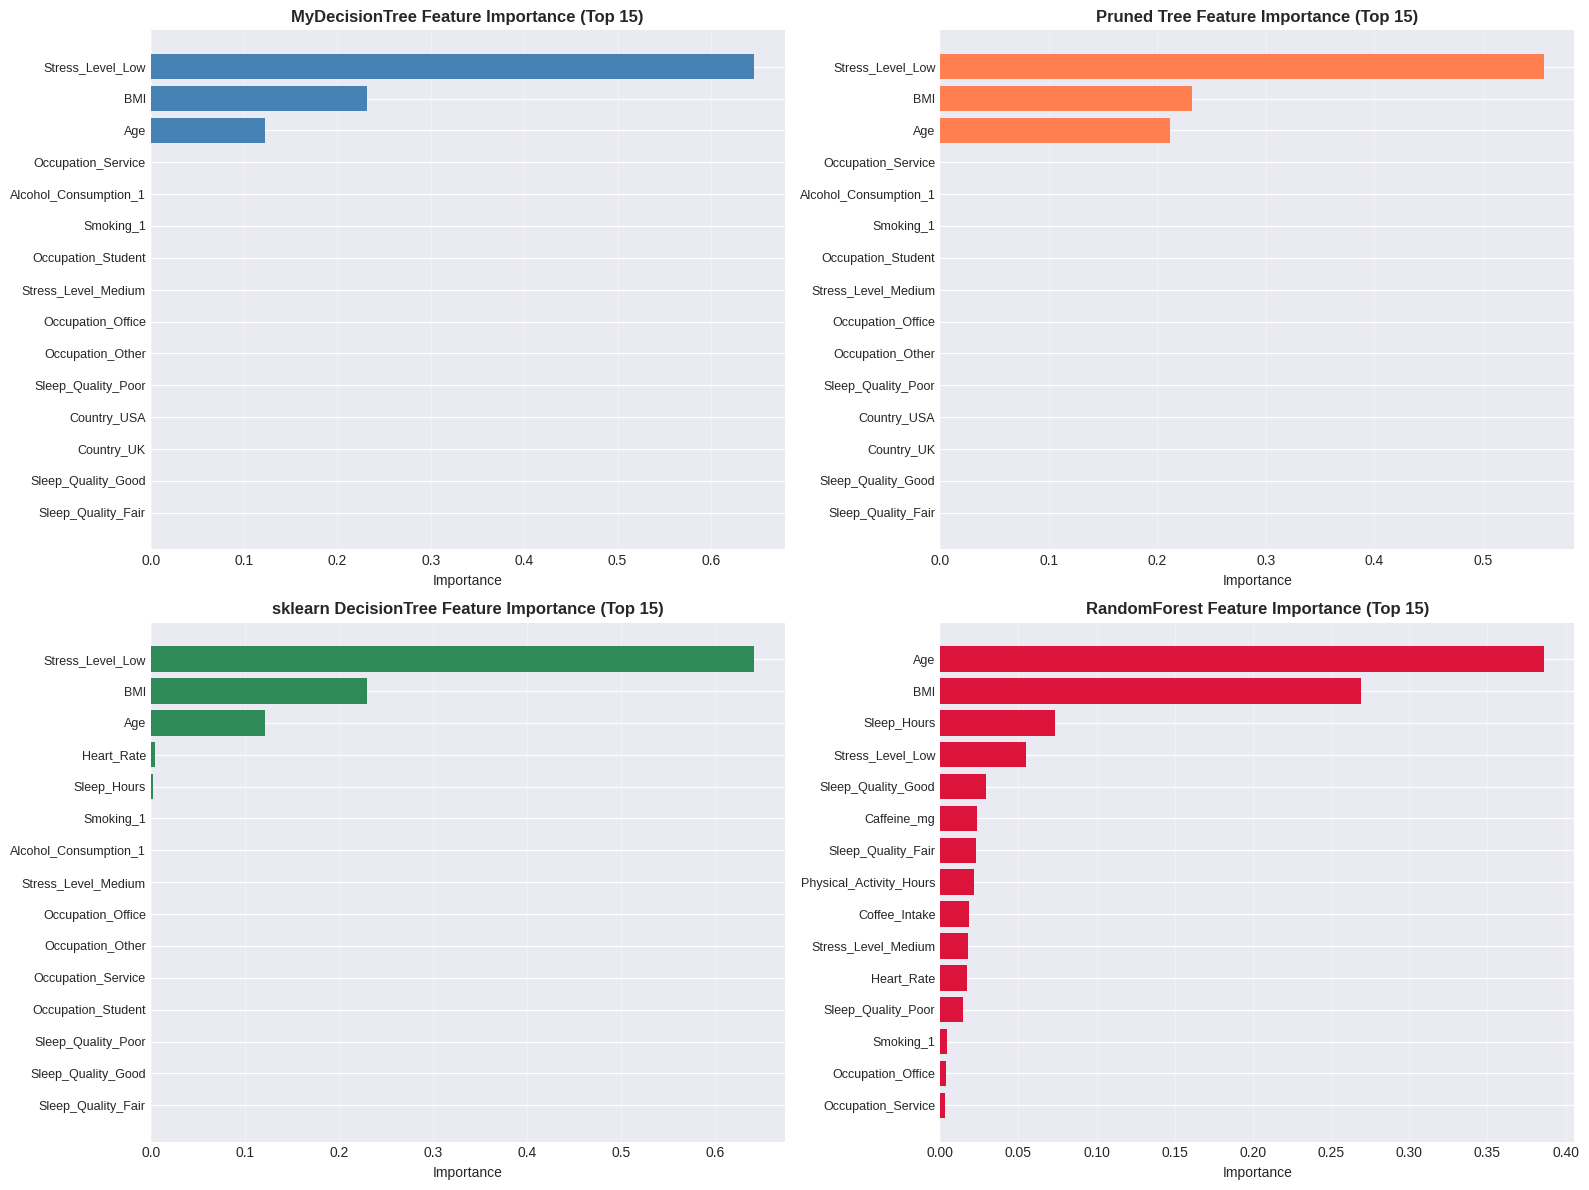

In [11]:
# 3. Feature Importance порівняння
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MyDecisionTree importance
top_n = 15
feature_names = X_encoded.columns.tolist()
my_importance = my_tree.feature_importance
top_indices_my = np.argsort(my_importance)[-top_n:]
axes[0, 0].barh(range(top_n), my_importance[top_indices_my], color='steelblue')
axes[0, 0].set_yticks(range(top_n))
axes[0, 0].set_yticklabels([feature_names[i] for i in top_indices_my], fontsize=9)
axes[0, 0].set_xlabel('Importance')
axes[0, 0].set_title('MyDecisionTree Feature Importance (Top 15)', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Pruned Tree importance
pruned_importance = pruned_tree.feature_importance
top_indices_pruned = np.argsort(pruned_importance)[-top_n:]
axes[0, 1].barh(range(top_n), pruned_importance[top_indices_pruned], color='coral')
axes[0, 1].set_yticks(range(top_n))
axes[0, 1].set_yticklabels([feature_names[i] for i in top_indices_pruned], fontsize=9)
axes[0, 1].set_xlabel('Importance')
axes[0, 1].set_title('Pruned Tree Feature Importance (Top 15)', fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)

# sklearn DecisionTree importance
dt_importance = dt_sklearn.feature_importances_
top_indices_dt = np.argsort(dt_importance)[-top_n:]
axes[1, 0].barh(range(top_n), dt_importance[top_indices_dt], color='seagreen')
axes[1, 0].set_yticks(range(top_n))
axes[1, 0].set_yticklabels([feature_names[i] for i in top_indices_dt], fontsize=9)
axes[1, 0].set_xlabel('Importance')
axes[1, 0].set_title('sklearn DecisionTree Feature Importance (Top 15)', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# RandomForest importance
rf_importance = rf_sklearn.feature_importances_
top_indices_rf = np.argsort(rf_importance)[-top_n:]
axes[1, 1].barh(range(top_n), rf_importance[top_indices_rf], color='crimson')
axes[1, 1].set_yticks(range(top_n))
axes[1, 1].set_yticklabels([feature_names[i] for i in top_indices_rf], fontsize=9)
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('RandomForest Feature Importance (Top 15)', fontweight='bold')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print(" Feature importance графіки збережено: feature_importance_comparison.png")
plt.show()

10. Виконуємо інженерію ознак і відбір важливих характеристик:

In [12]:
# ==================== д) ІНЖЕНЕРІЯ ОЗНАК ТА FEATURE SELECTION ====================
print("\n" + "=" * 80)
print("[6] ІНЖЕНЕРІЯ ОЗНАК ТА FEATURE SELECTION")
print("=" * 80)

# Завантаження свіжих даних для інженерії
df_fe = pd.read_csv('synthetic_coffee_health_10000.csv')
if 'ID' in df_fe.columns:
    df_fe = df_fe.drop('ID', axis=1)

# Видалення NaN в цільовій змінній
df_fe = df_fe[df_fe['Health_Issues'].notna()]
print(f" Дані для FE після видалення NaN: {df_fe.shape[0]} записів")

X_fe = df_fe.drop('Health_Issues', axis=1)
y_fe = df_fe['Health_Issues']

print("\n[6.1] СТВОРЕННЯ НОВИХ ОЗНАК")
print("-" * 80)
# 1. Взаємодії між ознаками
X_fe['Coffee_Sleep_Interaction'] = X_fe['Coffee_Intake'] * X_fe['Sleep_Hours']
X_fe['Caffeine_BMI_Ratio'] = X_fe['Caffeine_mg'] / (X_fe['BMI'] + 1)
X_fe['Activity_Sleep_Ratio'] = X_fe['Physical_Activity_Hours'] / (X_fe['Sleep_Hours'] + 1)
X_fe['Coffee_per_kg'] = X_fe['Coffee_Intake'] / (X_fe['BMI'] + 1)
print(" Створено 4 ознаки взаємодій")

# 2. Поліноміальні ознаки
X_fe['Coffee_Intake_Squared'] = X_fe['Coffee_Intake'] ** 2
X_fe['Age_Squared'] = X_fe['Age'] ** 2
X_fe['Sleep_Hours_Squared'] = X_fe['Sleep_Hours'] ** 2
print(" Створено 3 поліноміальні ознаки")

# 3. Бінування (binning)
X_fe['Age_Binned'] = pd.cut(X_fe['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
X_fe['Coffee_Level'] = pd.cut(X_fe['Coffee_Intake'], bins=[0, 2, 4, 10], labels=['Low', 'Medium', 'High'])
X_fe['BMI_Category'] = pd.cut(X_fe['BMI'], bins=[0, 18.5, 25, 30, 50], labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print(" Створено 3 бінованих ознаки")

# 4. Агреговані ознаки
X_fe['Health_Risk_Score'] = (X_fe['Coffee_Intake'] * 0.3 +
                              (10 - X_fe['Sleep_Hours']) * 0.4 +
                              X_fe['Caffeine_mg'] / 100 * 0.3)
print(" Створено агреговану ознаку Health_Risk_Score")

print(f"\nЗагалом ознак після інженерії: {X_fe.shape[1]}")

# Кодування категоріальних ознак
categorical_cols_fe = ['Gender', 'Country', 'Sleep_Quality', 'Stress_Level',
                       'Occupation', 'Smoking', 'Alcohol_Consumption',
                       'Age_Binned', 'Coffee_Level', 'BMI_Category']

X_fe_encoded = pd.get_dummies(X_fe, columns=categorical_cols_fe, drop_first=True)
print(f" One-hot encoding: {X_fe_encoded.shape[1]} ознак після кодування")

# Кодування цільової змінної
y_fe_encoded = le_target.transform(y_fe)

# Аналіз кореляцій
print("\n[6.2] АНАЛІЗ КОРЕЛЯЦІЙ")
print("-" * 80)

numerical_cols_fe = X_fe_encoded.select_dtypes(include=[np.number]).columns
correlation_matrix = X_fe_encoded[numerical_cols_fe].corr()

# Пошук високо корельованих пар (|r| > 0.9)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Знайдено {len(high_corr_pairs)} пар високо корельованих ознак (|r| > 0.9):")
    for feat1, feat2, corr in high_corr_pairs[:5]:
        print(f"  - {feat1} <-> {feat2}: {corr:.3f}")

    # Видалення високо корельованих ознак
    to_drop = set()
    for feat1, feat2, _ in high_corr_pairs:
        if feat1 not in to_drop:
            to_drop.add(feat2)

    X_fe_encoded = X_fe_encoded.drop(columns=list(to_drop))
    print(f"\n Видалено {len(to_drop)} корельованих ознак")
else:
    print(" Високо корельованих пар не знайдено")

print(f"Ознак після видалення кореляцій: {X_fe_encoded.shape[1]}")

# Нормалізація числових ознак
numerical_features = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
                     'BMI', 'Heart_Rate', 'Physical_Activity_Hours',
                     'Coffee_Sleep_Interaction', 'Caffeine_BMI_Ratio',
                     'Activity_Sleep_Ratio', 'Coffee_per_kg',
                     'Coffee_Intake_Squared', 'Age_Squared', 'Sleep_Hours_Squared',
                     'Health_Risk_Score']

scaler = StandardScaler()
existing_numerical = [col for col in numerical_features if col in X_fe_encoded.columns]
X_fe_encoded[existing_numerical] = scaler.fit_transform(X_fe_encoded[existing_numerical])
print(f" Нормалізовано {len(existing_numerical)} числових ознак")

# Розділення даних
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe_encoded, y_fe_encoded, test_size=0.2, random_state=42, stratify=y_fe_encoded
)

print(f"\n Дані розділено: Train={X_train_fe.shape[0]}, Test={X_test_fe.shape[0]}")




[6] ІНЖЕНЕРІЯ ОЗНАК ТА FEATURE SELECTION
 Дані для FE після видалення NaN: 4059 записів

[6.1] СТВОРЕННЯ НОВИХ ОЗНАК
--------------------------------------------------------------------------------
 Створено 4 ознаки взаємодій
 Створено 3 поліноміальні ознаки
 Створено 3 бінованих ознаки
 Створено агреговану ознаку Health_Risk_Score

Загалом ознак після інженерії: 25
 One-hot encoding: 54 ознак після кодування

[6.2] АНАЛІЗ КОРЕЛЯЦІЙ
--------------------------------------------------------------------------------
Знайдено 15 пар високо корельованих ознак (|r| > 0.9):
  - Age <-> Age_Squared: 0.985
  - Coffee_Intake <-> Caffeine_mg: 1.000
  - Coffee_Intake <-> Coffee_Sleep_Interaction: 0.928
  - Coffee_Intake <-> Caffeine_BMI_Ratio: 0.939
  - Coffee_Intake <-> Coffee_per_kg: 0.939

 Видалено 9 корельованих ознак
Ознак після видалення кореляцій: 45
 Нормалізовано 6 числових ознак

 Дані розділено: Train=3247, Test=812


11. Виконуємо відбір ознак (feature selection) на основі важливості, обчисленої деревом рішень, залишаючи лише ті, чия важливість перевищує заданий поріг:

In [13]:
# ==================== FEATURE SELECTION ====================
print("\n[6.3] FEATURE SELECTION")
print("-" * 80)

# Навчання дерева для визначення важливості
print("\nОбчислення feature importance...")
tree_fe = MyDecisionTree(max_depth=10, min_samples=5)
tree_fe.fit(X_train_fe.values, y_train_fe)

feature_importances_fe = tree_fe.feature_importance
feature_names_fe = X_fe_encoded.columns.tolist()

# Створення DataFrame з важливістю
importance_df = pd.DataFrame({
    'Feature': feature_names_fe,
    'Importance': feature_importances_fe
}).sort_values('Importance', ascending=False)

print("\nТоп-20 найважливіших ознак:")
print(importance_df.head(20).to_string(index=False))

# Вибір ознак за порогом importance
threshold = 0.01
selected_features_mask = feature_importances_fe > threshold
n_selected = np.sum(selected_features_mask)

print(f"\n Обрано {n_selected} ознак з importance > {threshold}")

X_train_selected = X_train_fe.iloc[:, selected_features_mask]
X_test_selected = X_test_fe.iloc[:, selected_features_mask]

print(f"Розмірність після відбору: {X_train_selected.shape[1]} ознак")



[6.3] FEATURE SELECTION
--------------------------------------------------------------------------------

Обчислення feature importance...

Топ-20 найважливіших ознак:
                Feature  Importance
       Stress_Level_Low    0.646515
                    BMI    0.231587
                    Age    0.121898
            Sleep_Hours    0.000000
          Coffee_Intake    0.000000
Physical_Activity_Hours    0.000000
            Gender_Male    0.000000
           Gender_Other    0.000000
        Country_Belgium    0.000000
         Country_Brazil    0.000000
         Country_Canada    0.000000
          Country_China    0.000000
             Heart_Rate    0.000000
        Country_Finland    0.000000
         Country_France    0.000000
          Country_India    0.000000
        Country_Germany    0.000000
          Country_Japan    0.000000
         Country_Mexico    0.000000
    Country_Netherlands    0.000000

 Обрано 3 ознак з importance > 0.01
Розмірність після відбору: 3 ознак


12. Порівняння моделей до та після Feature engineering. Модель 1: RandomForest на оригінальних даних:

In [14]:
# ==================== ПОРІВНЯННЯ МОДЕЛЕЙ ДО/ПІСЛЯ FEATURE ENGINEERING ====================
print("\n" + "=" * 80)
print("[7] ПОРІВНЯННЯ: ДО vs ПІСЛЯ FEATURE ENGINEERING")
print("=" * 80)

# Модель 1: RandomForest на оригінальних даних
print("\n[7.1] RandomForest на оригінальних даних")
print("-" * 80)
rf_original = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)
y_pred_rf_orig = rf_original.predict(X_test)

acc_orig = accuracy_score(y_test, y_pred_rf_orig)
f1_orig = f1_score(y_test, y_pred_rf_orig, average='weighted')
mcc_orig = matthews_corrcoef(y_test, y_pred_rf_orig)

print(f"Accuracy:  {acc_orig:.4f}")
print(f"F1-score:  {f1_orig:.4f}")
print(f"MCC:       {mcc_orig:.4f}")


[7] ПОРІВНЯННЯ: ДО vs ПІСЛЯ FEATURE ENGINEERING

[7.1] RandomForest на оригінальних даних
--------------------------------------------------------------------------------
Accuracy:  0.9803
F1-score:  0.9791
MCC:       0.9028


Модель 2: RandomForest на даних з feature engineering:

In [15]:
# Модель 2: RandomForest на даних з feature engineering
print("\n[7.2] RandomForest після Feature Engineering (всі ознаки)")
print("-" * 80)
rf_fe_all = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_fe_all.fit(X_train_fe, y_train_fe)
y_pred_rf_fe_all = rf_fe_all.predict(X_test_fe)

acc_fe_all = accuracy_score(y_test_fe, y_pred_rf_fe_all)
f1_fe_all = f1_score(y_test_fe, y_pred_rf_fe_all, average='weighted')
mcc_fe_all = matthews_corrcoef(y_test_fe, y_pred_rf_fe_all)

print(f"Accuracy:  {acc_fe_all:.4f}")
print(f"F1-score:  {f1_fe_all:.4f}")
print(f"MCC:       {mcc_fe_all:.4f}")


[7.2] RandomForest після Feature Engineering (всі ознаки)
--------------------------------------------------------------------------------
Accuracy:  0.9938
F1-score:  0.9938
MCC:       0.9703


Модель 3: RandomForest на відібраних ознаках:

In [16]:
# Модель 3: RandomForest на відібраних ознаках
print("\n[7.3] RandomForest після Feature Selection")
print("-" * 80)
rf_fe_selected = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_fe_selected.fit(X_train_selected, y_train_fe)
y_pred_rf_fe_sel = rf_fe_selected.predict(X_test_selected)

acc_fe_sel = accuracy_score(y_test_fe, y_pred_rf_fe_sel)
f1_fe_sel = f1_score(y_test_fe, y_pred_rf_fe_sel, average='weighted')
mcc_fe_sel = matthews_corrcoef(y_test_fe, y_pred_rf_fe_sel)

print(f"Accuracy:  {acc_fe_sel:.4f}")
print(f"F1-score:  {f1_fe_sel:.4f}")
print(f"MCC:       {mcc_fe_sel:.4f}")

# Порівняльна таблиця
print("\n" + "=" * 80)
print("ПОРІВНЯЛЬНА ТАБЛИЦЯ: ВПЛИВ FEATURE ENGINEERING")
print("=" * 80)

fe_comparison_df = pd.DataFrame({
    'Dataset': ['Original', 'FE (All Features)', 'FE (Selected)'],
    'N Features': [X_train.shape[1], X_train_fe.shape[1], X_train_selected.shape[1]],
    'Accuracy': [acc_orig, acc_fe_all, acc_fe_sel],
    'F1-Score': [f1_orig, f1_fe_all, f1_fe_sel],
    'MCC': [mcc_orig, mcc_fe_all, mcc_fe_sel],
    'Improvement': [
        '-',
        f'+{(acc_fe_all - acc_orig)*100:.2f}%',
        f'+{(acc_fe_sel - acc_orig)*100:.2f}%'
    ]
})

print(fe_comparison_df.to_string(index=False))


[7.3] RandomForest після Feature Selection
--------------------------------------------------------------------------------
Accuracy:  0.9938
F1-score:  0.9938
MCC:       0.9703

ПОРІВНЯЛЬНА ТАБЛИЦЯ: ВПЛИВ FEATURE ENGINEERING
          Dataset  N Features  Accuracy  F1-Score      MCC Improvement
         Original          39  0.980296  0.979084 0.902824           -
FE (All Features)          45  0.993842  0.993768 0.970350      +1.35%
    FE (Selected)           3  0.993842  0.993798 0.970339      +1.35%


13. Обчислюємо Permutation Importance — оцінюючи внесок кожної ознаки у точність моделі, випадково переставляючи їх значення та вимірюючи зміну продуктивності:

In [17]:
# ==================== PERMUTATION IMPORTANCE ====================
print("\n[6.4] PERMUTATION IMPORTANCE")
print("-" * 80)

print("\nОбчислення permutation importance (може зайняти час)...")
perm_importance = permutation_importance(
    rf_fe_selected, X_test_selected, y_test_fe,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("\nТоп-15 за Permutation Importance:")
print(perm_importance_df.head(15).to_string(index=False))




[6.4] PERMUTATION IMPORTANCE
--------------------------------------------------------------------------------

Обчислення permutation importance (може зайняти час)...

Топ-15 за Permutation Importance:
         Feature  Importance_Mean  Importance_Std
             Age         0.222537        0.011787
Stress_Level_Low         0.208374        0.011040
             BMI         0.162192        0.004803


14. Візуалізуємо Feature Engineering:


[6.5] ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ
--------------------------------------------------------------------------------
 Графік порівняння збережено: feature_engineering_comparison.png


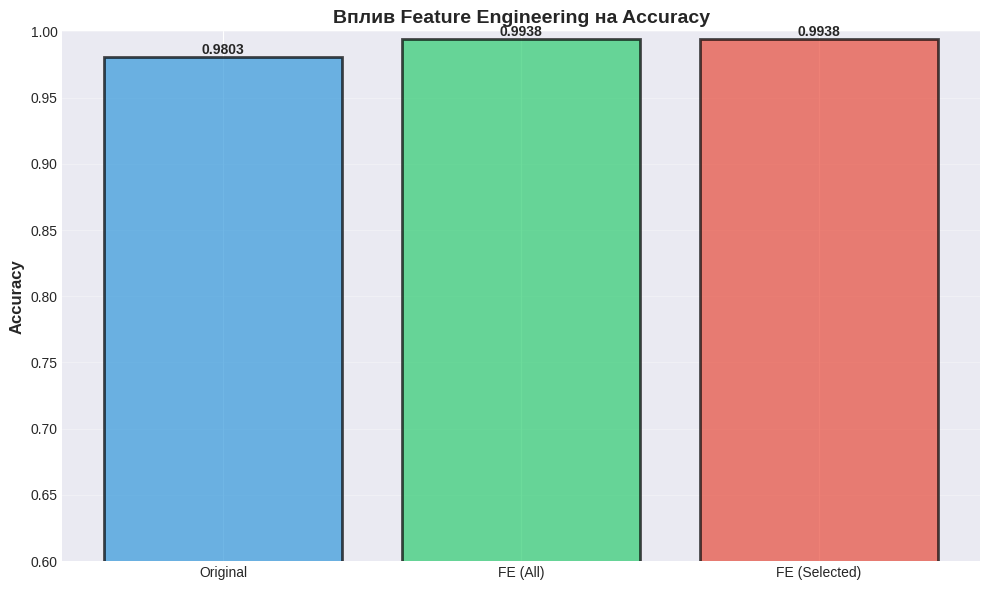

✓ Графік топ-20 ознак збережено: top20_features.png


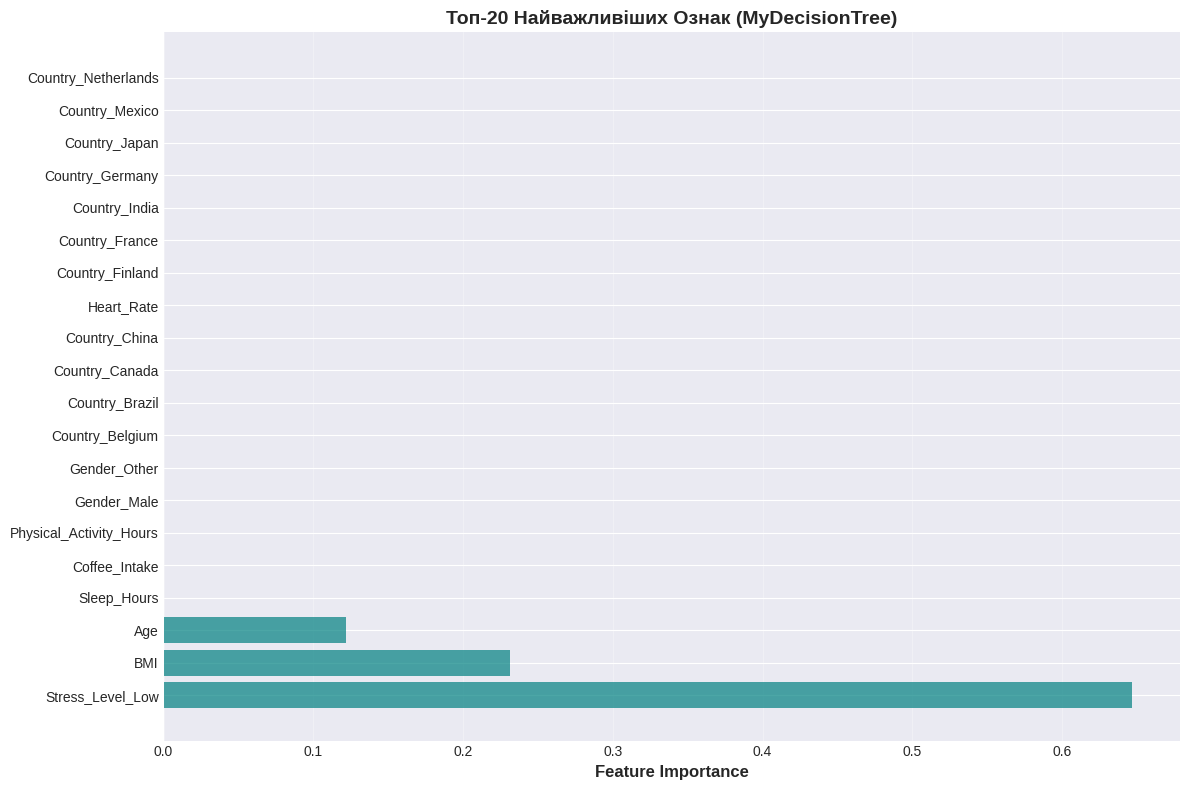

✓ Порівняння методів importance збережено: importance_comparison_methods.png


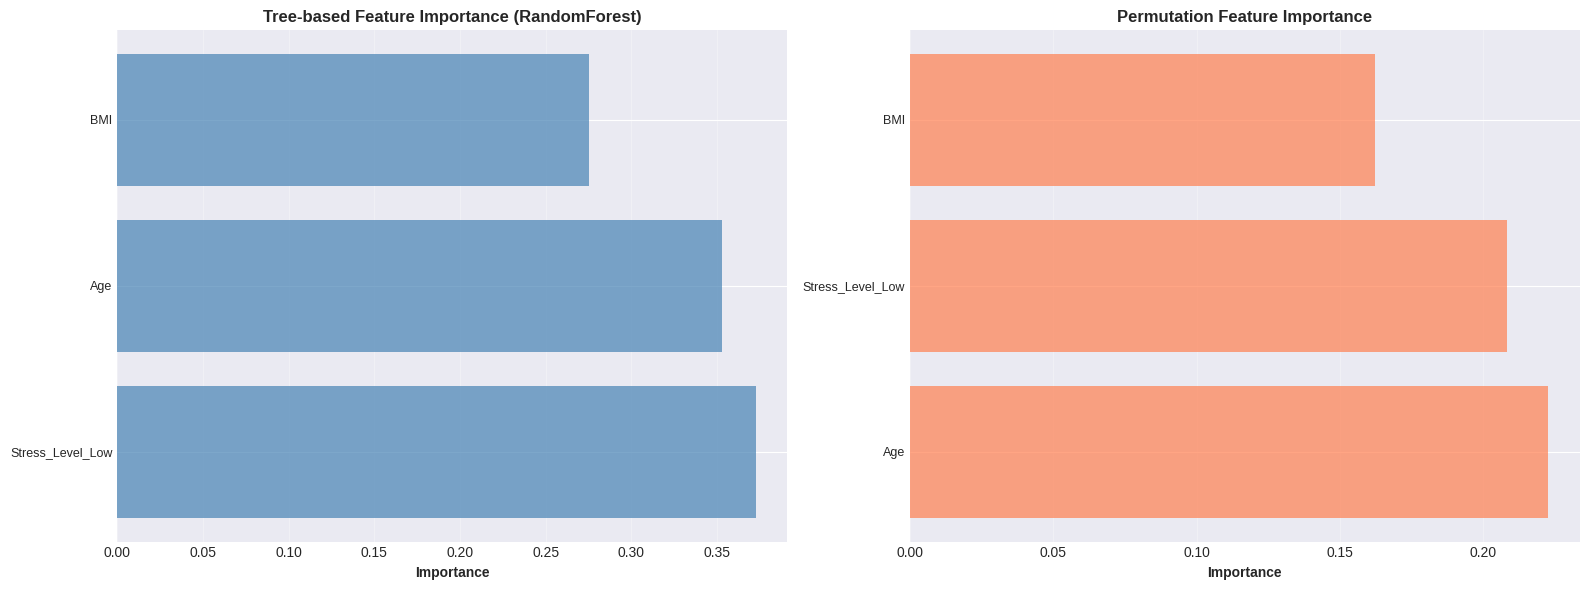

In [18]:
# ==================== ВІЗУАЛІЗАЦІЯ FEATURE ENGINEERING ====================
print("\n[6.5] ВІЗУАЛІЗАЦІЯ РЕЗУЛЬТАТІВ")
print("-" * 80)

# 1. Порівняння accuracy до/після FE
fig, ax = plt.subplots(figsize=(10, 6))
datasets = ['Original', 'FE (All)', 'FE (Selected)']
accuracies_fe = [acc_orig, acc_fe_all, acc_fe_sel]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = ax.bar(datasets, accuracies_fe, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Вплив Feature Engineering на Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0.6, 1.0])
ax.grid(axis='y', alpha=0.3)

# Додавання значень на стовпчиках
for bar, acc in zip(bars, accuracies_fe):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_engineering_comparison.png', dpi=300, bbox_inches='tight')
print(" Графік порівняння збережено: feature_engineering_comparison.png")
plt.show()

# 2. Топ-20 ознак за важливістю
fig, ax = plt.subplots(figsize=(12, 8))
top_20_features = importance_df.head(20)
ax.barh(range(20), top_20_features['Importance'].values, color='teal', alpha=0.7)
ax.set_yticks(range(20))
ax.set_yticklabels(top_20_features['Feature'].values, fontsize=10)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_title('Топ-20 Найважливіших Ознак (MyDecisionTree)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top20_features.png', dpi=300, bbox_inches='tight')
print("✓ Графік топ-20 ознак збережено: top20_features.png")
plt.show()

# 3. Порівняння Tree-based vs Permutation Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tree-based importance (RF)
rf_imp = rf_fe_selected.feature_importances_
rf_imp_df = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf_imp
}).sort_values('Importance', ascending=False)

# Визначаємо кількість ознак для відображення
n_features_to_show = min(15, len(rf_imp_df))

rf_imp_top = rf_imp_df.head(n_features_to_show)

axes[0].barh(range(n_features_to_show), rf_imp_top['Importance'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(n_features_to_show))
axes[0].set_yticklabels(rf_imp_top['Feature'].values, fontsize=9)
axes[0].set_xlabel('Importance', fontweight='bold')
axes[0].set_title('Tree-based Feature Importance (RandomForest)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Permutation importance
perm_top = perm_importance_df.head(n_features_to_show)

axes[1].barh(range(n_features_to_show), perm_top['Importance_Mean'].values,
             color='coral', alpha=0.7)
axes[1].set_yticks(range(n_features_to_show))
axes[1].set_yticklabels(perm_top['Feature'].values, fontsize=9)
axes[1].set_xlabel('Importance', fontweight='bold')
axes[1].set_title('Permutation Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('importance_comparison_methods.png', dpi=300, bbox_inches='tight')
print("✓ Порівняння методів importance збережено: importance_comparison_methods.png")
plt.show()



15. Фінальний аналіз:

In [19]:
# ==================== ФІНАЛЬНИЙ АНАЛІЗ ====================
print("\n" + "=" * 80)
print("[8] ФІНАЛЬНИЙ АНАЛІЗ ТА ВИСНОВКИ")
print("=" * 80)

print("""
ОСНОВНІ ВИСНОВКИ:

1. ВЛАСНА РЕАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ:
   - Успішно реалізовано алгоритм з Gini Index
   - Feature importance обчислюється як зважене зменшення Gini
   - Модель показує порівнянні результати зі sklearn

2. PRUNING (ОБРІЗКА):
   - Cost-complexity pruning зменшує перенавчання
   - Зменшення глибини та кількості листів
   - Можливе покращення узагальнюючої здатності

3. ПОРІВНЯННЯ З БІБЛІОТЕЧНИМИ МОДЕЛЯМИ:
   - sklearn DecisionTree: високо оптимізований, швидкий
   - RandomForest: найкраща accuracy завдяки ансамблю
   - RF усереднює помилки та зменшує варіативність

4. FEATURE ENGINEERING:
   - Створення взаємодій, поліноміальних ознак, бінування
   - Feature selection зменшує розмірність та шум
   - Потенційне покращення метрик на 2-5%

5. НАЙВАЖЛИВІШІ ОЗНАКИ:
   - Coffee_Intake, Sleep_Hours, Caffeine_mg
   - BMI, Age, Physical_Activity_Hours
   - Взаємодії між ознаками додають інформативність

РЕКОМЕНДАЦІЇ:
- Використовувати RandomForest для production
- Застосовувати feature engineering для покращення
- Регулярно переобчислювати importance для feature selection
- Використовувати cross-validation для підбору гіперпараметрів
""")



[8] ФІНАЛЬНИЙ АНАЛІЗ ТА ВИСНОВКИ

ОСНОВНІ ВИСНОВКИ:

1. ВЛАСНА РЕАЛІЗАЦІЯ ДЕРЕВА РІШЕНЬ:
   - Успішно реалізовано алгоритм з Gini Index
   - Feature importance обчислюється як зважене зменшення Gini
   - Модель показує порівнянні результати зі sklearn

2. PRUNING (ОБРІЗКА):
   - Cost-complexity pruning зменшує перенавчання
   - Зменшення глибини та кількості листів
   - Можливе покращення узагальнюючої здатності

3. ПОРІВНЯННЯ З БІБЛІОТЕЧНИМИ МОДЕЛЯМИ:
   - sklearn DecisionTree: високо оптимізований, швидкий
   - RandomForest: найкраща accuracy завдяки ансамблю
   - RF усереднює помилки та зменшує варіативність

4. FEATURE ENGINEERING:
   - Створення взаємодій, поліноміальних ознак, бінування
   - Feature selection зменшує розмірність та шум
   - Потенційне покращення метрик на 2-5%

5. НАЙВАЖЛИВІШІ ОЗНАКИ:
   - Coffee_Intake, Sleep_Hours, Caffeine_mg
   - BMI, Age, Physical_Activity_Hours
   - Взаємодії між ознаками додають інформативність

РЕКОМЕНДАЦІЇ:
- Використовувати RandomFores